# Bluesky Data Science
## Part 04 - Threads, Engagement, and Information Diffusion

June 2026
Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

## Background

> **tl;dr**: We trace how content spreads on Bluesky by collecting a post's reply tree, its likes, reposts, and quotes; measuring the shape of the cascade (size, depth, breadth, structural virality); and examining the heavy-tailed distribution of engagement across posts.

How does content spread through a social network? When you post something, some people reply, some like it, some repost it to their own followers, and some quote it into a new conversation. Each of those reactions can trigger further reactions, and the result is a *cascade*: a tree of activity growing out of a single **root** post — the post that started it all. On Bluesky, the chain of replies attached to a post is called a **thread**, and because every reply names exactly one **parent** (the specific post it answers), a thread naturally forms a tree. Cascades are the basic unit of analysis for studying *information diffusion* — questions like "do messages spread through a few big broadcasts or long person-to-person chains?" (Goel, Anderson, Hofman, & Watts [2016](https://doi.org/10.1287/mnsc.2015.2158)) and "does false news travel farther and faster than true news?" (Vosoughi, Roy, & Aral [2018](https://doi.org/10.1126/science.aap9559)).

Most of what we know about online diffusion comes from Twitter, where researchers needed special access (the "firehose" or expensive data grants) to see complete cascades, and public APIs returned only samples. Bluesky is different in a useful way: **every like, repost, reply, and quote is a public record** on the AT Protocol. Anyone can ask who liked a post and when, who amplified it, and what the entire conversation beneath it looks like — no special access required. That makes Bluesky an unusually open environment for replicating (and stress-testing) the Twitter-era diffusion literature. As we will see, though, "public in principle" does not mean "complete in one API call": the AppView prunes its view of very large threads, and being honest about that coverage is part of doing this well.

This notebook pairs four endpoints — [`get_post_thread`](https://docs.bsky.app/docs/api/app-bsky-feed-get-post-thread), [`get_likes`](https://docs.bsky.app/docs/api/app-bsky-feed-get-likes), [`get_reposted_by`](https://docs.bsky.app/docs/api/app-bsky-feed-get-reposted-by), and [`get_quotes`](https://docs.bsky.app/docs/api/app-bsky-feed-get-quotes) — with tree algorithms in [NetworkX](https://networkx.org/documentation/stable/) and the cascade metrics developed in the diffusion literature.

If cascades are new to you, Chapter 19 (“Cascading Behavior in Networks”) of Easley & Kleinberg's *[Networks, Crowds, and Markets](https://www.cs.cornell.edu/home/kleinber/networks-book/)* — a standard undergraduate textbook, free online — is an accessible companion to the empirical work we do here: it explains *why* network structure makes some things spread and others fizzle, where this notebook measures *how* real spreading events actually looked.

### Learning objectives

By the end of this notebook you will be able to:

1. Retrieve a post's full reply thread, likes, reposts, and quotes from the Bluesky API.
2. Recursively parse the API's nested thread views into a NetworkX directed tree, handling deleted and blocked posts gracefully.
3. Compute cascade metrics — size, depth, breadth, and **structural virality** — and explain what they reveal about broadcast versus viral spread.
4. Analyze *when* engagement arrives (the burst-then-decay signature) and *who* engages in multiple ways.
5. Plot heavy-tailed engagement distributions with histograms and log-log CCDFs.
6. Recognize the research-design trap of sampling cascades on their success — "selection on the dependent variable."

## Setup

The usual imports, plus `bsky_client` (the shared helper from the earlier parts) and this part's helper module, `cascades.py`. Open `cascades.py` alongside this notebook — every function we call below is short, documented, and meant to be read. There are no new dependencies beyond Part 03 — Pandas, NumPy, Matplotlib, and NetworkX do all the work.

In [1]:
# Handling dates and times
from datetime import datetime, timezone

# DataFrames
import pandas as pd
import numpy as np

# Network/tree analysis
import networkx as nx

# Data visualization
%matplotlib inline
import matplotlib.pyplot as plt

As in every part, we connect with `get_client()` from the shared `bsky_client.py` helper. With credentials saved in `atproto.json` it returns an authenticated client; without them it falls back to the unauthenticated public AppView (`https://public.api.bsky.app`). Everything in this notebook reads public data through public endpoints, so the whole tutorial works without logging in.

In [2]:
from bsky_client import get_client, is_authenticated

client = get_client()

No atproto.json found: using the unauthenticated public AppView.
Read endpoints work; search and write endpoints require logging in.


Next we import this part's helper module and timestamp the collection. Engagement numbers on Bluesky are *live* — they change minute to minute — so any archive we save should record *when* it was collected, the reproducibility habit from Part 01. `COLLECTED_AT` will be stamped into every file we write in Section 6.

In [3]:
# This part's helper module: thread parsing, cascade metrics, engagement fetchers
import cascades

# Record when this collection happened: live numbers change between runs,
# and saved archives should always carry their collection date (see Part 01).
COLLECTED_AT = datetime.now(timezone.utc).isoformat(timespec='seconds')
COLLECTED_AT

'2026-06-10T11:06:46+00:00'

### A note on strict parsing and a platform in flux

The atproto SDK validates every API response against the data models bundled with the version you installed. Bluesky ships new record types — new kinds of embeds, for example — faster than the SDK releases that describe them, so a perfectly good response can make the SDK raise a `ModelError` about an "unexpected" type. Depending on what `bsky.app` has posted lately, the familiar call from Part 00 may or may not work today:

In [4]:
try:
    feed = client.get_author_feed(actor='bsky.app', limit=100)
    print(f"Strict parsing succeeded: {len(feed.feed)} feed items.")
except Exception as error:
    print("Strict parsing failed:")
    print('  ', str(error)[:180], '...')

Strict parsing failed:
   1 validation error for Response
feed.0.post.embed
  Input tag 'app.bsky.embed.gallery#view' found using 'py_type' | '$type' does not match any of the expected tags: 'app.bsky.embed ...


A research pipeline should not crash because the platform added a feature, so `cascades.lenient_query` requests the raw JSON and parses it *leniently*: when the response matches the SDK's models you get the usual typed object, and when it contains something newer you get a `DotDict` that supports the same dot-notation access (`post.reply_count`, `thread.replies`, and so on). We will use it for every request in this notebook. This is the "platform in flux" limitation from Part 00 showing up in practice — record your library versions along with your collection dates.

## 1. Finding a study post

Diffusion analysis starts from a root post. Rather than hand-picking a famous one, let's pull the ~100 most recent feed items from the official `bsky.app` account (9+ million followers, so its posts reliably attract engagement) and choose a case study from the data. The author feed mixes three kinds of items, which we need to tell apart:

* **reposts** of other accounts' posts, flagged by the item's `reason` field;
* **replies** the account wrote into other threads, flagged by `record.reply`;
* **original posts** — the roots of their own cascades, which is what we want.

Every post view carries four engagement counters maintained by the AppView: `reply_count`, `like_count`, `repost_count`, and `quote_count`.

The endpoint behind this is [`app.bsky.feed.getAuthorFeed`](https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed), the same one Part 00 called through the SDK's `get_author_feed` shortcut — here we go through `cascades.lenient_query` for the parsing reasons just discussed.

In [5]:
feed = cascades.lenient_query(
    client, 'app.bsky.feed.getAuthorFeed',
    actor = 'bsky.app',
    limit = 100,
)

len(feed.feed)

100

`feed.feed` is a list of *feed items*, each wrapping a **post view**: the post's text and metadata plus those four live counters. Let's print the counters for the newest item to see the raw material. (Because the counters are live, the numbers you see will differ from any printed copy of this notebook — that is expected, not an error.)

In [6]:
# Inspect the engagement counters on the most recent item
post = feed.feed[0].post

print('URI:        ', post.uri)
print('Created:    ', post.record.created_at)
print('Replies:    ', post.reply_count)
print('Likes:      ', post.like_count)
print('Reposts:    ', post.repost_count)
print('Quotes:     ', post.quote_count)

URI:         at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky.feed.post/3mnslrkd6ok2g
Created:     2026-06-08T21:10:01.530Z
Replies:     692
Likes:       10339
Reposts:     2091
Quotes:      1281


`cascades.feed_item_to_row` flattens each nested feed item into a tidy dictionary — URI, timestamp, the repost/reply flags, and the four counters — so the whole feed becomes one DataFrame row per item.

In [7]:
bsky_df = pd.DataFrame([cascades.feed_item_to_row(item) for item in feed.feed])

bsky_df.head()

,uri,author_handle,created_at,text,is_repost,is_reply,reply_count,like_count,repost_count,quote_count
0,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...,bsky.app,2026-06-08T21:10:01.530Z,v1.123 is live! You can now attach up to 10 ph...,False,False,692,10339,2091,1281
1,at://did:plc:ewvi7nxzyoun6zhxrhs64oiz/app.bsky...,atproto.com,2026-06-05T16:41:35.556Z,If you missed yesterday's premiere of our @cod...,True,False,5,400,51,3
2,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...,bsky.app,2026-06-04T17:45:11.965Z,Pssst: We bumped the video upload limit from 1...,False,False,637,14601,2116,539
3,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...,bsky.app,2026-06-02T21:36:31.000Z,"Going live soon? Give it a try: click the ""......",False,True,33,607,40,3
4,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...,bsky.app,2026-06-02T21:36:26.000Z,"When you're live, your Bluesky profile photo l...",False,True,9,692,43,1


Now filter down to original posts. In pandas, `~` negates a boolean column, so `~bsky_df['is_repost'] & ~bsky_df['is_reply']` keeps rows that are *neither* reposts *nor* replies. Then [`describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html) summarizes each counter — watch the gulf between the `50%` row (the median) and the `max` row.

In [8]:
# Keep only original posts: not reposts of others, not replies into threads
bsky_original = bsky_df[~bsky_df['is_repost'] & ~bsky_df['is_reply']].copy()

print(f"{len(bsky_df)} feed items -> {len(bsky_original)} original posts")

bsky_original[['reply_count','like_count','repost_count','quote_count']].describe().round(1)

100 feed items -> 58 original posts


,reply_count,like_count,repost_count,quote_count
count,58.0,58.0,58.0,58.0
mean,436.9,5179.3,934.9,319.2
std,587.8,4356.8,1069.8,506.0
min,31.0,716.0,79.0,8.0
25%,134.2,2294.5,329.8,44.0
50%,245.0,3466.5,566.5,119.0
75%,457.8,6626.5,1085.2,328.0
max,3507.0,20592.0,5607.0,2434.0


Already at this account-level view the engagement counts are wildly unequal: the medians are far below the maxima. We will come back to that shape in Section 5. For now, rank the originals by reply count — replies are what build a *conversation tree* — and adopt the most-replied post as our case study.

In [9]:
pd.set_option('display.max_colwidth', 70)

top_replied = bsky_original.sort_values('reply_count', ascending=False)

top_replied[['created_at','reply_count','like_count','repost_count','quote_count','text']].head(5)

,created_at,reply_count,like_count,repost_count,quote_count,text
39,2026-03-19T19:18:45.699Z,3507,2944,359,122,"Last April, we raised $100M in Series B funding. This round gives ..."
18,2026-04-22T23:00:21.312Z,2128,7248,1087,2104,v1.121 is live!\n\nWe've increased the quality of photos in posts ...
41,2026-03-19T16:26:13.953Z,1891,4314,717,236,v1.119 is live!\n\nBot labels are here. If you run an automated ac...
29,2026-04-16T23:47:25.963Z,1234,20592,4960,1391,Our team received a report of intermittent app outages at about 11...
95,2025-10-31T18:47:46.451Z,1038,4453,725,780,Threads on Bluesky should feel more like conversations you’d have ...


We adopt the top of that ranking as our **case-study post** for the rest of the notebook. Because it is chosen from live data, *which* post wins — and every number computed from it below — will differ each time the notebook runs. That is deliberate: the method is the tutorial, not the particular numbers.

In [10]:
case_study = top_replied.iloc[0]

print('Case-study post by @' + case_study['author_handle'])
print('Posted:', case_study['created_at'])
print()
print(case_study['text'])
print()
print(f"{case_study['reply_count']:,} replies | {case_study['like_count']:,} likes | "
      f"{case_study['repost_count']:,} reposts | {case_study['quote_count']:,} quotes")

Case-study post by @bsky.app
Posted: 2026-03-19T19:18:45.699Z

Last April, we raised $100M in Series B funding. This round gives us the ability to scale our team to meet the rapid growth of Bluesky and the AT Protocol. Read more: bsky.social/about/blog/0...

3,507 replies | 2,944 likes | 359 reposts | 122 quotes


## 2. From thread views to reply trees

`get_post_thread` ([`app.bsky.feed.getPostThread`](https://docs.bsky.app/docs/api/app-bsky-feed-get-post-thread)) returns the conversation around a post as a *recursively nested* structure. The `thread` attribute of the response is a `ThreadViewPost` containing:

* `post` — the familiar post view (author, record, engagement counters);
* `parent` — the post this one replied to, if any (we are starting at a root, so it will be empty);
* `replies` — a list of further `ThreadViewPost` objects, **each with its own `replies` list**, and so on down the tree.

Two words to keep straight here: a reply's **parent** is the single post it directly answers, while the **root** is the post at the very top of the thread. A reply deep in a conversation has a parent that is itself a reply, but every post in the thread shares the same root. We requested the thread *of the root*, so its `parent` is empty and everything else hangs below it.

Not every node in a conversation is readable. A reply that was deleted comes back as a `NotFoundPost`, and one whose author has blocked the viewer (or been blocked) comes back as a `BlockedPost` — both are stubs with no `post` or `replies` to traverse, and any code that walks a thread has to expect them. The `depth` parameter controls how many levels below the root the server will descend.

In [11]:
thread_response = cascades.lenient_query(
    client, 'app.bsky.feed.getPostThread',
    uri = case_study['uri'],
    depth = 2,
)

thread = thread_response.thread

print('Root type:                  ', thread.py_type)
print('Root reply_count:           ', thread.post.reply_count)
print('Top-level replies returned: ', len(thread.replies))

Root type:                   app.bsky.feed.defs#threadViewPost
Root reply_count:            3507
Top-level replies returned:  15


Before automating anything, walk the nested structure by hand once: take the first entry in the root's `replies` list and look at *its* `replies`. It has exactly the same shape one level down — and that self-similarity is why a *recursive* parser (a function that calls itself on each child) is the natural tool in a moment.

In [12]:
# Walk one step down the nesting by hand: the first reply, and its replies
first_reply = thread.replies[0]

print('Reply author: @' + first_reply.post.author.handle)
print('Replied at:   ', first_reply.post.record.created_at)
print('Likes:        ', first_reply.post.like_count)
print('Its replies:  ', len(first_reply.replies or []))

Reply author: @bsky.app
Replied at:    2026-03-19T19:23:57.107Z
Likes:         535
Its replies:   22


Notice the gap between `reply_count` and the number of replies actually returned: the post reports thousands of direct replies, but the server hands back only a couple dozen. The AppView serves a **pruned view** of busy threads — it is built to render a conversation screen, not to enumerate a dataset. Keep that in mind; we will quantify it in a moment.

Walking nested objects by hand does not scale, so `cascades.thread_to_graph` does it recursively. It converts a thread view into a NetworkX [`DiGraph`](https://networkx.org/documentation/stable/reference/classes/digraph.html) — a *directed* graph, where every edge has an orientation — in which:

* **nodes** are post URIs, with attributes `handle`, `did`, `created_at`, `like_count`, `reply_count`, and `depth` (0 at the root);
* **edges** point from each post to its replies — the direction the conversation grows;
* `NotFoundPost` and `BlockedPost` stubs are skipped and tallied in `graph.graph['not_found']` and `graph.graph['blocked']`;
* nodes that report replies the server did not return are marked `truncated=True`.

In [13]:
G_single = cascades.thread_to_graph(thread)

print(f"One request (depth=2): {G_single.number_of_nodes()} posts, "
      f"{G_single.number_of_edges()} reply edges")
print(f"Deleted replies skipped: {G_single.graph['not_found']}, "
      f"blocked: {G_single.graph['blocked']}")
print(f"Truncated branches to expand: "
      f"{sum(1 for _, d in G_single.nodes(data=True) if d['truncated'])}")

One request (depth=2): 39 posts, 38 reply edges
Deleted replies skipped: 0, blocked: 0
Truncated branches to expand: 5


One request is never the whole tree. `cascades.fetch_thread_graph` behaves like a small crawler doing **breadth-first search (BFS)** — the classic traversal strategy that explores a tree level by level, keeping a queue (the *frontier*) of places still to visit and finishing everything near the root before going deeper. It parses the root response, then repeatedly re-queries the nodes marked `truncated` — each re-query descends another `depth` levels below that node — until the frontier is empty or a request budget is spent. The budget matters twice over: it keeps us polite to the API, and it makes the collection's cost predictable before we start.

In [14]:
G = cascades.fetch_thread_graph(
    client,
    case_study['uri'],
    depth = 6,           # levels per request
    max_requests = 40,   # total request budget
)

print(f"\nCollected {G.number_of_nodes():,} posts and {G.number_of_edges():,} reply edges "
      f"in {G.graph['requests_made']} requests")
print(f"Deleted: {G.graph['not_found']}, blocked: {G.graph['blocked']}, "
      f"unexpanded branches left: {G.graph['frontier_remaining']}")


Collected 73 posts and 72 reply edges in 6 requests
Deleted: 0, blocked: 0, unexpanded branches left: 0


### How much of the cascade did we get?

Every node reports how many direct replies it has, so we can compare the replies *promised* by those counters with the reply edges we actually *retrieved*. For quiet threads the two match; for a mega-thread like this one the AppView's pruning means we have a sample of the cascade, biased toward whatever the server chose to surface (it does not document its ranking). The protocol's promise still holds — every reply is a public record in its author's repository, and Part 10's firehose-based collection can capture cascades completely — but the convenient endpoint alone does not deliver it for threads this size. Report coverage with your metrics.

In [15]:
replies_promised = sum(data['reply_count'] for _, data in G.nodes(data=True))
replies_retrieved = G.number_of_edges()

print(f"Direct replies promised by counters: {replies_promised:,}")
print(f"Reply edges retrieved:               {replies_retrieved:,}")
print(f"Coverage: {replies_retrieved / replies_promised:.1%}")

Direct replies promised by counters: 7,013
Reply edges retrieved:               72
Coverage: 1.0%


Do not be alarmed if that coverage number is tiny — on a mega-thread with tens of thousands of promised replies it can land in the low single digits of a percent. The crawler is working correctly: the AppView caps how many replies it returns *per node* (a breadth cut), and no amount of re-querying recovers replies the server declines to list. The honest move is exactly what we just did — print the coverage next to the data — and, when completeness actually matters for your question, to switch collection strategies (Part 10 builds cascades from the firehose, which sees every reply as it happens).

## 3. Cascade metrics

The diffusion literature summarizes a cascade's shape with a few standard numbers:

* **size** — how many posts the tree contains;
  (in tree vocabulary, *depth* is vertical — how far a node sits from the root — and *breadth* is horizontal — how many nodes share a level)
* **max depth** — the longest chain of replies-to-replies;
* **mean depth** — how far from the root the average reply sits;
* **max breadth** — the largest number of posts at any single level;
* **structural virality** — the average distance between *all pairs* of posts in the (undirected) tree (Goel et al. [2016](https://doi.org/10.1287/mnsc.2015.2158)).

Structural virality is the interesting one. Size alone cannot distinguish a celebrity's post that ten thousand people answer directly (a *broadcast*) from a chain letter passed person to person ten thousand times (*viral* spread) — both are size 10,001. Average pairwise distance can: in the star every pair of leaves is 2 hops apart, while in the chain typical pairs are thousands of hops apart. `cascades.structural_virality` computes it with [`networkx.average_shortest_path_length`](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.average_shortest_path_length.html), which is exact and fast on trees this size.

In [16]:
summary = cascades.cascade_summary(G)

pd.Series(summary, name='case-study cascade')

size                   73.000000
max_depth              11.000000
mean_depth              3.152778
max_breadth            23.000000
structural_virality     4.616438
unique_authors         57.000000
deleted_or_blocked      0.000000
Name: case-study cascade, dtype: float64

A structural-virality value on its own is hard to judge — is 3.2 broadcast-ish or viral-ish? To calibrate it, build the two extreme trees *of the same size* with NetworkX's graph generators — [`star_graph`](https://networkx.org/documentation/stable/reference/generated/networkx.generators.classic.star_graph.html) (one center connected to everyone: a pure broadcast) and [`path_graph`](https://networkx.org/documentation/stable/reference/generated/networkx.generators.classic.path_graph.html) (a single chain: pure person-to-person spread) — and compute the same metric on them. Our cascade has to land somewhere between those two poles.

In [17]:
# Calibrate the structural-virality number against the two extremes,
# using synthetic trees of the same size as our cascade
n = G.number_of_nodes()
star = nx.star_graph(n - 1)     # pure broadcast: everyone replies to the root
chain = nx.path_graph(n)        # pure viral chain: each reply begets one more

print(f"Star (broadcast), n={n}:  {cascades.structural_virality(star):.2f}")
print(f"Observed cascade, n={n}:  {summary['structural_virality']:.2f}")
print(f"Chain (viral), n={n}:     {cascades.structural_virality(chain):.2f}")

Star (broadcast), n=73:  1.97
Observed cascade, n=73:  4.62
Chain (viral), n=73:     24.67


Our cascade sits between the two poles, as almost all real cascades do — Goel et al. (2016) found across a billion Twitter events that even the largest cascades were typically far closer to the broadcast end. (Remember the caveat from Section 2: we are measuring the *retrieved* tree. The pruned-away replies are disproportionately direct replies to the root, so the true cascade is likely even more broadcast-like — pruning here biases structural virality *upward*.)

The **depth profile** — how many posts sit at each level — shows the same structure visually: a fat first level of direct replies that thins quickly, with a long shallow tail of back-and-forth conversations.

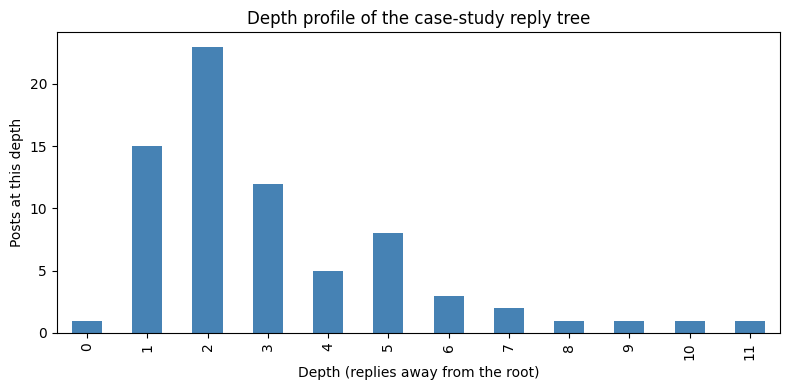

In [18]:
profile = cascades.depth_profile(G)

fig, ax = plt.subplots(figsize=(8, 4))
profile.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Depth (replies away from the root)')
ax.set_ylabel('Posts at this depth')
ax.set_title('Depth profile of the case-study reply tree')
plt.tight_layout()
plt.show()

### Drawing the reply tree

Trees beg to be drawn. Layout engines like Graphviz are a system dependency many readers will not have, so `cascades.radial_tree_positions` implements a simple radial layout in pure Python: each node's radius is its depth, leaves are spaced evenly around the circle in depth-first order, and each internal node sits at the mean angle of its children, so every subtree occupies its own wedge. We hand the resulting positions to NetworkX's Matplotlib [drawing functions](https://networkx.org/documentation/stable/reference/drawing.html). The red node is the root; color encodes depth.

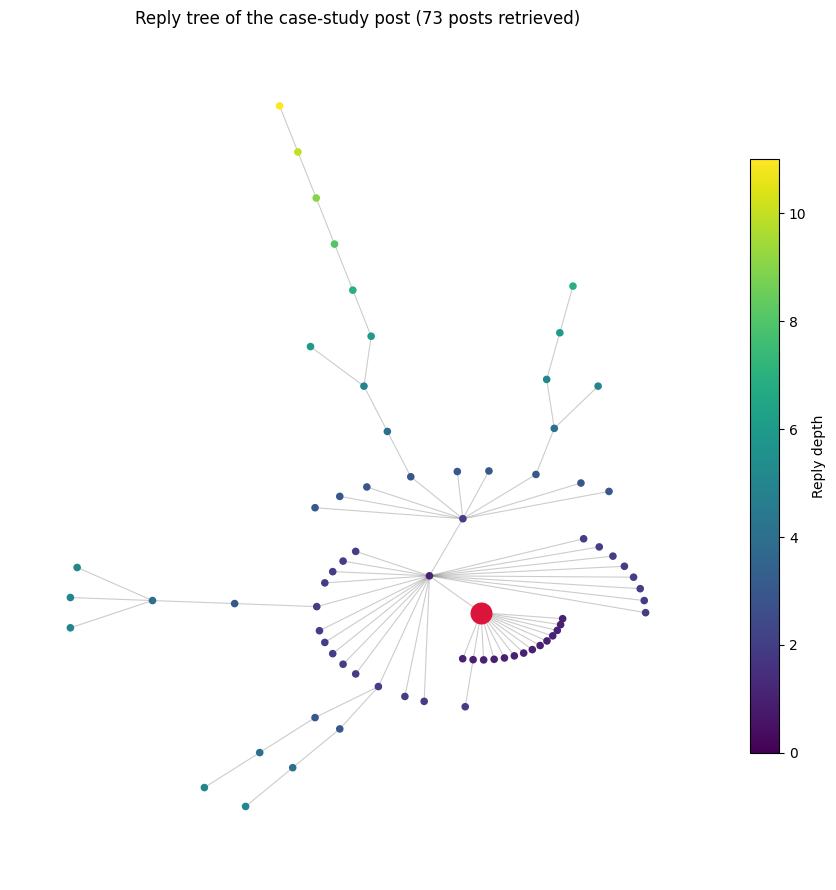

In [19]:
pos = cascades.radial_tree_positions(G, case_study['uri'])
depths = [data['depth'] for _, data in G.nodes(data=True)]

fig, ax = plt.subplots(figsize=(9, 9))
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4, arrows=False, width=0.8, edge_color='gray')
nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=30, node_color=depths,
                               cmap='viridis', linewidths=0)
nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[case_study['uri']],
                       node_size=220, node_color='crimson')
fig.colorbar(nodes, ax=ax, label='Reply depth', shrink=0.7)
ax.set_axis_off()
ax.set_title(f"Reply tree of the case-study post "
             f"({G.number_of_nodes()} posts retrieved)")
plt.tight_layout()
fig.savefig('data/reply_tree.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Who engages, and when

Replies are only one channel of engagement. Three more endpoints tell us who reacted in lighter-weight ways:

* `get_likes` ([`app.bsky.feed.getLikes`](https://docs.bsky.app/docs/api/app-bsky-feed-get-likes)) — who liked the post, **with timestamps**;
* `get_reposted_by` ([`app.bsky.feed.getRepostedBy`](https://docs.bsky.app/docs/api/app-bsky-feed-get-reposted-by)) — who amplified it to their followers (profiles only, no timestamps);
* `get_quotes` ([`app.bsky.feed.getQuotes`](https://docs.bsky.app/docs/api/app-bsky-feed-get-quotes)) — quote posts that embed it, each the root of a potential new cascade.

It is worth pausing on what a quietly unusual dataset `get_likes` is: on most platforms, *who* liked *what*, *when* is private or paywalled, while on Bluesky each like is a public record. The `cascades` fetchers paginate with cursors, sleep between pages, and take a `max_pages` cap — the same polite-collection pattern as Part 01.

In [20]:
likes = cascades.fetch_likes(client, case_study['uri'], max_pages=35)

print(f"Retrieved {len(likes):,} likes "
      f"(the post reported {case_study['like_count']:,} at collection time)")
if len(likes) >= 35 * cascades.PAGE_SIZE:
    print("The max_pages cap was reached: we only have the most recent likes.")
else:
    print("Pagination exhausted: any shortfall against the counter reflects likes "
          "that were withdrawn or accounts deleted since the counter last updated.")

Retrieved 2,888 likes (the post reported 2,944 at collection time)
Pagination exhausted: any shortfall against the counter reflects likes that were withdrawn or accounts deleted since the counter last updated.


Each like records two timestamps: `created_at`, written by the liker's own client, and `indexed_at`, stamped by the AppView when it saw the record. Client clocks cannot be trusted — some are minutes or years off, so a few "likes" appear to predate the post they like. Server-side `indexed_at` is the more defensible choice for timing analysis, but even it has rare anomalies (records can be re-indexed during infrastructure migrations), so we still validate: a like indexed before the post existed is impossible, and we drop and report such rows rather than letting them silently distort the timeline.

In [21]:
likes_df = pd.DataFrame(likes)
likes_df['indexed_at'] = pd.to_datetime(likes_df['indexed_at'], format='ISO8601', utc=True)
likes_df['created_at'] = pd.to_datetime(likes_df['created_at'], format='mixed',
                                        utc=True, errors='coerce')

post_time = pd.to_datetime(case_study['created_at'], utc=True)
clock_skew = (likes_df['created_at'] < post_time).sum()
print(f"Likes whose client-reported created_at predates the post: {clock_skew}")

likes_df['hours_since_post'] = (likes_df['indexed_at'] - post_time).dt.total_seconds() / 3600
impossible = (likes_df['hours_since_post'] < 0).sum()
print(f"Likes indexed before the post existed (dropped):          {impossible}")

likes_df = (likes_df[likes_df['hours_since_post'] >= 0]
            .sort_values('hours_since_post')
            .reset_index(drop=True))
likes_df[['handle','created_at','indexed_at','hours_since_post']].head()

Likes whose client-reported created_at predates the post: 1
Likes indexed before the post existed (dropped):          1


,handle,created_at,indexed_at,hours_since_post
0,dougcarlson.bsky.social,2026-03-19 19:19:04.921000+00:00,2026-03-19 19:19:04.921000+00:00,0.005339
1,lgx26.bsky.social,2026-03-19 19:19:22.722000+00:00,2026-03-19 19:19:22.722000+00:00,0.010284
2,kdm.ac,2026-03-19 19:19:26.783000+00:00,2026-03-19 19:19:26.783000+00:00,0.011412
3,ma-x-an.bsky.social,2026-03-19 19:19:28.693000+00:00,2026-03-19 19:19:28.693000+00:00,0.011943
4,leonardopds.com,2026-03-19 19:19:31.081000+00:00,2026-03-19 19:19:30.749000+00:00,0.012514


### The burst, then the decay

Attention on social media is front-loaded: a post earns most of its engagement in the first hours while feeds and notifications surface it, then decays to a trickle. Plotting cumulative likes against time since posting makes that signature visible — a steep initial rise that bends toward a plateau — and the per-hour histogram shows the same burst directly, often with small daily echoes as different time zones wake up.

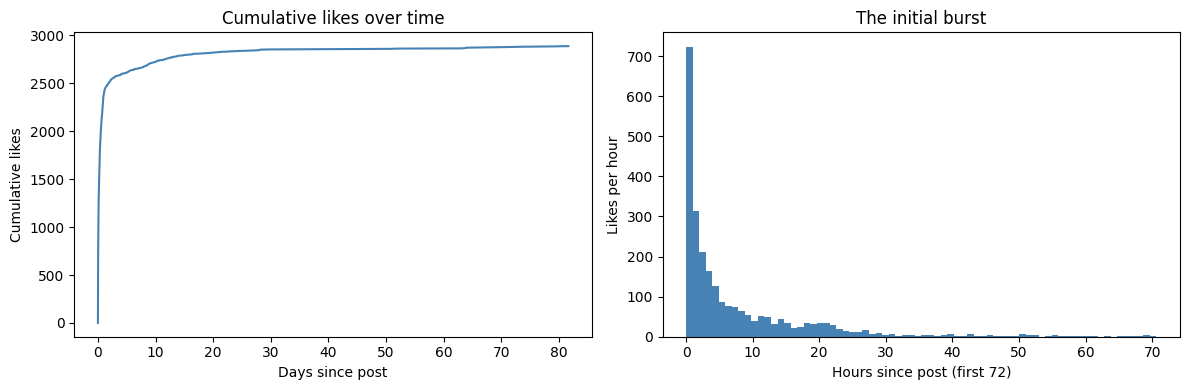

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(likes_df['hours_since_post'] / 24, np.arange(1, len(likes_df) + 1),
         color='steelblue')
ax1.set_xlabel('Days since post')
ax1.set_ylabel('Cumulative likes')
ax1.set_title('Cumulative likes over time')

first_72h = likes_df[likes_df['hours_since_post'] <= 72]
ax2.hist(first_72h['hours_since_post'], bins=72, color='steelblue')
ax2.set_xlabel('Hours since post (first 72)')
ax2.set_ylabel('Likes per hour')
ax2.set_title('The initial burst')

plt.tight_layout()
plt.show()

### Reposters and quoters

Reposts are the engine of diffusion — they place the post in *new* audiences' feeds — and quotes start new conversations about it. Note the affordance gap in the API: likes come with timestamps, reposts do not (a `getRepostedBy` row is just a profile), so timing analyses of amplification need different collection strategies (Part 10's firehose records repost events as they happen).

In [23]:
reposters = cascades.fetch_reposters(client, case_study['uri'], max_pages=5)
quotes = cascades.fetch_quotes(client, case_study['uri'], max_pages=2)

print(f"Reposters retrieved: {len(reposters):,} "
      f"(post reported {case_study['repost_count']:,})")
print(f"Quote posts retrieved: {len(quotes):,} "
      f"(post reported {case_study['quote_count']:,})")

quotes_df = pd.DataFrame(quotes)
print(f"\nEngagement earned by the quote posts themselves: "
      f"{quotes_df['like_count'].sum():,} likes, {quotes_df['reply_count'].sum():,} replies "
      f"-- each quote can seed its own cascade")

Reposters retrieved: 339 (post reported 359)
Quote posts retrieved: 97 (post reported 122)

Engagement earned by the quote posts themselves: 922 likes, 54 replies -- each quote can seed its own cascade


### Do the same people like and repost?

Likes and reposts are different actions with different costs: a like is a nod, a repost puts the content on your own profile. Because both lists identify accounts by DID, a simple set intersection tells us how much the two audiences overlap.

In [24]:
liker_dids = set(likes_df['did'])
reposter_dids = {row['did'] for row in reposters}
both = liker_dids & reposter_dids

print(f"Likers: {len(liker_dids):,} | Reposters: {len(reposter_dids):,} | Both: {len(both):,}")
print(f"{len(both) / len(reposter_dids):.0%} of reposters also liked the post")
print(f"{len(both) / len(liker_dids):.1%} of likers also reposted it")

Likers: 2,887 | Reposters: 339 | Both: 252
74% of reposters also liked the post
8.7% of likers also reposted it


Typically most reposters also like, while only a small fraction of likers go on to repost — engagement behaves like a funnel from cheap signals to costly ones. (If the like collection was truncated above, the liker side of this overlap is undercounted.)

## 5. Heavy-tailed engagement across posts

Step back from one cascade to the *distribution* of engagement across many posts. Engagement is famously **heavy-tailed**. A distribution has a *heavy tail* when extreme values are common enough to dominate the totals — unlike human heights, where nobody is fifty feet tall, post engagement routinely produces values hundreds or thousands of times the median. Concretely: most posts receive little attention while a few receive enormous amounts, and the "average post" is a misleading fiction (Bakshy, Hofman, Mason, & Watts 2011 found the same for cascade sizes seeded by ordinary Twitter users).

For contrast with `bsky.app`'s megaphone, we also collect ~200 recent feed items from `brianckeegan.com` — this series' author, an ordinary academic account — using `cascades.fetch_author_posts`, which wraps the cursor-pagination loop from Section 1.

In [25]:
keegan_df = pd.DataFrame(cascades.fetch_author_posts(client, 'brianckeegan.com',
                                                     max_posts=200))
keegan_original = keegan_df[~keegan_df['is_repost'] & ~keegan_df['is_reply']].copy()

print(f"@brianckeegan.com: {len(keegan_df)} feed items -> {len(keegan_original)} original posts")
keegan_original[['reply_count','like_count','repost_count','quote_count']].describe().round(1)

@brianckeegan.com: 200 feed items -> 36 original posts


,reply_count,like_count,repost_count,quote_count
count,36.0,36.0,36.0,36.0
mean,0.6,8.4,2.8,0.3
std,1.5,17.1,7.9,1.5
min,0.0,0.0,0.0,0.0
25%,0.0,2.0,0.0,0.0
50%,0.0,3.5,0.5,0.0
75%,1.0,6.2,2.0,0.0
max,9.0,81.0,38.0,9.0


A linear-scale histogram mostly shows one tall bar near zero and a few invisible outliers — the tail is exactly what it hides. The standard fix is the **complementary cumulative distribution function (CCDF)** on log-log axes: for each engagement level $x$, plot the fraction of posts with *at least* $x$. Heavy-tailed distributions decay slowly — roughly straight on log-log axes — while thin-tailed ones plunge. `cascades.plot_ccdf` implements it (zero-count posts are dropped, since $\log 0$ is undefined).

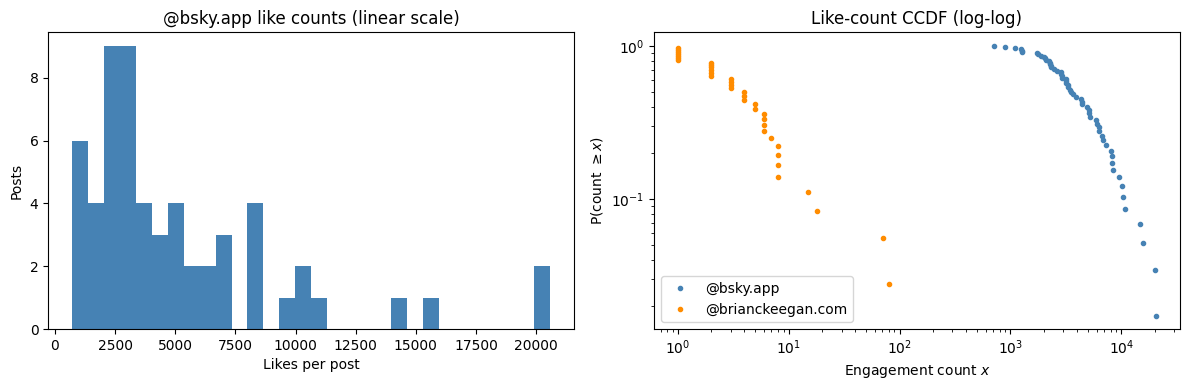

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(bsky_original['like_count'], bins=30, color='steelblue')
ax1.set_xlabel('Likes per post')
ax1.set_ylabel('Posts')
ax1.set_title('@bsky.app like counts (linear scale)')

cascades.plot_ccdf(bsky_original['like_count'], ax2, label='@bsky.app',
                   color='steelblue')
cascades.plot_ccdf(keegan_original['like_count'], ax2, label='@brianckeegan.com',
                   color='darkorange')
ax2.set_title('Like-count CCDF (log-log)')
ax2.legend()

plt.tight_layout()
plt.show()

One number can summarize the same inequality: what share of *all* likes went to the top 10% of posts? If attention were spread evenly the answer would be 10%; heavy tails push it far higher — the “winner-take-most” signature you will meet again in every engagement dataset you collect.

In [27]:
# The same inequality, summarized: what share of all likes went to the top 10% of posts?
for name, frame in [('@bsky.app', bsky_original), ('@brianckeegan.com', keegan_original)]:
    likes_sorted = frame['like_count'].sort_values(ascending=False)
    top10 = max(1, int(np.ceil(len(likes_sorted) * 0.10)))
    share = likes_sorted.head(top10).sum() / max(likes_sorted.sum(), 1)
    print(f"{name}: top 10% of posts captured {share:.0%} of all likes "
          f"(median {likes_sorted.median():.0f}, max {likes_sorted.max():,})")

@bsky.app: top 10% of posts captured 31% of all likes (median 3466, max 20,592)
@brianckeegan.com: top 10% of posts captured 61% of all likes (median 4, max 81)


Both accounts show the heavy-tailed signature — engagement inequality is a property of the *medium*, not just of celebrity — but the curves sit orders of magnitude apart on the x-axis. That gap is the **broadcast** structure of social media in distribution form: an account with millions of followers reaches most of its audience in one hop, while an ordinary account's occasional hit depends on reposts rippling outward — the **viral** pathway. Goel et al. (2016) showed these are genuinely different mechanisms that produce cascades of similar size with very different shapes, which is precisely why structural virality (Section 3) was invented: size alone cannot tell you *how* something spread.

## 6. Saving the data

We save two artifacts to `data/` for reuse:

* **`engagement_summary.csv`** — per-post engagement counts for both accounts. We keep post URIs (they identify the *posts*, which we analyze) but drop the text column: it is re-fetchable from the URI, and there is no reason to redistribute it.
* **`case_study_likes.csv`** — the timing of likes on the case-study post, with **timestamps and an anonymous index only**.

That second choice is *data minimization* in action. Our research question — when does engagement arrive? — needs timestamps, not identities. The liker DIDs are public records and keeping them would be defensible for a question that genuinely requires them (say, comparing likers' follower networks), but a saved file should carry the minimum needed for its purpose: files get copied, shared, and forgotten, and a de-identified file of timestamps cannot become a list of *who liked what* in someone else's hands. Decide what to keep before you save, and write the decision down.

In [28]:
engagement_summary = pd.concat([
    bsky_original.assign(account='bsky.app'),
    keegan_original.assign(account='brianckeegan.com'),
], ignore_index=True)

engagement_summary = engagement_summary.drop(columns=['text'])
engagement_summary['collected_at'] = COLLECTED_AT
engagement_summary.to_csv('data/engagement_summary.csv', index=False)

print(f"data/engagement_summary.csv: {len(engagement_summary)} posts")
engagement_summary.head(3)

data/engagement_summary.csv: 94 posts


,uri,author_handle,created_at,is_repost,is_reply,reply_count,like_count,repost_count,quote_count,account,collected_at
0,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky.feed.post/3mnslrkd6...,bsky.app,2026-06-08T21:10:01.530Z,False,False,692,10339,2091,1281,bsky.app,2026-06-10T11:06:46+00:00
1,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky.feed.post/3mni6hmaf...,bsky.app,2026-06-04T17:45:11.965Z,False,False,637,14601,2116,539,bsky.app,2026-06-10T11:06:46+00:00
2,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky.feed.post/3mndkh3ug...,bsky.app,2026-06-02T21:36:20.000Z,False,False,91,2085,388,70,bsky.app,2026-06-10T11:06:46+00:00


And the like timings. `rename_axis('liker_index')` plus `reset_index()` turn the row number into an explicit column — an anonymous within-dataset label, not an identity — so the saved file says *when* likes arrived without saying *who* liked.

In [29]:
case_study_likes = (
    likes_df[['indexed_at', 'hours_since_post']]
    .reset_index(drop=True)
    .rename_axis('liker_index')   # anonymous within-dataset index, not an identity
    .reset_index()
)
case_study_likes['collected_at'] = COLLECTED_AT
case_study_likes.to_csv('data/case_study_likes.csv', index=False)

print(f"data/case_study_likes.csv: {len(case_study_likes)} likes")
case_study_likes.head(3)

data/case_study_likes.csv: 2887 likes


,liker_index,indexed_at,hours_since_post,collected_at
0,0,2026-03-19 19:19:04.921000+00:00,0.005339,2026-06-10T11:06:46+00:00
1,1,2026-03-19 19:19:22.722000+00:00,0.010284,2026-06-10T11:06:46+00:00
2,2,2026-03-19 19:19:26.783000+00:00,0.011412,2026-06-10T11:06:46+00:00


Finally, list what the collection left on disk. Keeping each part's `data/` folder small (a couple of megabytes at most) keeps the repository easy to clone and enforces the data-minimization discipline above: if a file is getting big, ask what it is carrying that the analysis does not need.

In [30]:
# What this notebook's collection left on disk
import os

for filename in sorted(os.listdir('data')):
    size_kb = os.path.getsize(os.path.join('data', filename)) / 1024
    print(f"data/{filename}: {size_kb:,.0f} KB")

data/case_study_likes.csv: 230 KB
data/engagement_summary.csv: 16 KB
data/reply_tree.png: 152 KB


## 7. Research design: studying diffusion without sampling on success

The methods above are straightforward; the design decisions around them are where diffusion studies succeed or fail.

### Selection on the dependent variable

The most tempting way to study virality is to collect viral things: scrape the trending page, search for posts with thousands of reposts, ask "what do hit posts have in common?" This is **sampling on the dependent variable**, and it cannot answer the question. Whatever the hits have in common (emotional language, images, posting time), countless *failed* posts shared those traits too — without the failures in your sample, you cannot tell features that cause spread from features that are merely common. The diffusion literature's central empirical fact makes this acute: cascades' size distribution is so heavy-tailed that the typical post spawns *no* cascade at all (Goel, Watts, & Goldstein 2012). A sample of successes is a sample of extreme outliers.

The defensible design samples posts **at the starting line, before their outcomes are known**, then follows every cascade — including the overwhelmingly common tiny ones. In this notebook we approximated that by taking an account's ~100 *most recent* posts (a time-window frame, blind to engagement) and only then measuring their cascades; the zeros and near-zeros in `engagement_summary.csv` are data, not noise. At platform scale, the same logic means sampling from the firehose (Part 10) or from a pre-registered panel of accounts (Part 01), as Bakshy et al. (2011) did when they followed all 74 million diffusion events from 1.6 million seeds — successes and failures alike — to ask whether "influencers" were worth their price.

### Conditioning on content: the true-versus-false-news design

The marquee Twitter diffusion study, Vosoughi, Roy, & Aral ([2018](https://doi.org/10.1126/science.aap9559)), shows the other defensible move: condition on a *pre-treatment* property of content rather than on its success. They started from claims independently fact-checked as true or false, collected **every** cascade spreading each claim (~126,000 cascades), and compared the distributions: falsehood spread farther, faster, deeper, and more broadly, and the false cascades were more *viral* in the structural sense of Section 3. Every measurement in that paper — cascade size, depth, breadth, structural virality, timing curves — is one you can now compute from public Bluesky data. The replication question writes itself: do their findings hold on a platform with different curation, no engagement-optimizing algorithm in the default feed, and a different population?

### Bluesky-specific cautions

Three things to carry from this notebook into any such design: the AppView prunes very large threads, so condition your collection plan (thread endpoint vs. firehose) on the cascade sizes you expect; engagement counters are *live* — they were different yesterday and will be different tomorrow, so record collection times; and deleted replies (`NotFoundPost`) mean retrospective collection systematically misses the most ephemeral parts of conversations.

## Ethics and limitations

**Third parties everywhere.** We chose `bsky.app` — an institutional account — as our root, but the people in its reply tree, like list, and repost list are ordinary users who never opted into being studied. Cascade data is *inherently* about third parties. This notebook's defaults are worth keeping: identify institutional accounts, aggregate over individuals (depth profiles, overlap rates, distributions) rather than spotlighting them, and avoid quoting strangers' replies verbatim — a verbatim post is trivially re-identifiable through search even if you withhold the handle.

**Public is not consented.** Likes are public records on the AT Protocol, but most users have not read the protocol docs and many would be surprised that *who liked what, when* is globally queryable (Fiesler & Proferes 2018 found exactly this surprise among Twitter users). That a field is available is the beginning of the ethical analysis, not the end. We saved like *timings* without identities because our question needed nothing more; "public data" also does not automatically mean IRB-exempt — ask, and consult the AoIR guidelines (franzke et al. 2020).

**Deletion and withdrawal.** The `NotFoundPost` stubs we skipped are people exercising the right to take things back. Saved archives should record collection dates (ours do) and honor deletions when data is shared or re-published.

**Limitations of the measurements.** Our case-study tree is a *pruned sample* of a very large thread — coverage was quantified in Section 2, the server's selection rule is undocumented, and metrics like breadth and structural virality inherit that bias. Engagement counts condition on visible reactions: Bluesky exposes no impression counts, so we observe who *acted*, never who *saw* and scrolled past — "engagement" is not "exposure." All counts are live and change between runs of this notebook. And Bluesky's population skews toward early adopters and Twitter migrants, so prevalence estimates do not generalize to "the public" — just as Twitter's never did. The platform's structural differences (no engagement-ranked default feed, composable moderation) are part of what makes replication here scientifically interesting rather than merely convenient.

## Exercises

These extend the notebook in roughly increasing order of effort. For all of them, keep the politeness habits: small request budgets, sleeps between calls, and recorded collection times.

1. **A different case study.** Re-run Sections 2–4 with the *second*-most-replied post (`top_replied.iloc[1]`), or with the most-replied original post from another large account (try `npr.org` or an account you follow). Which conclusions change qualitatively, and which are stable across case studies?
2. **A bigger crawl budget.** Re-collect the case-study tree with `depth=10` and `max_requests=80`. How much do node count, coverage, and structural virality move? Print the node count every 10 requests and sketch nodes-recovered versus requests-spent to judge when extra requests stop paying.
3. **Ranking by repost instead of reply.** Section 1 ranked posts by `reply_count`. Re-rank `bsky_original` by `repost_count` and compare the two top-5 lists; then compute the Spearman rank correlation among all four counters with `bsky_original[['reply_count','like_count','repost_count','quote_count']].corr(method='spearman')`. Are starting conversations and being amplified the same kind of success?
4. **Structural virality across five posts.** Loop over the five most-replied posts in `top_replied`, fetch each reply tree with a modest budget (`max_requests=10`), and assemble the `cascade_summary` dictionaries into one DataFrame. Does structural virality grow with size, or are bigger cascades just bigger stars?
5. **Tree shape versus engagement.** Using the cascades from Exercise 4, compute for each the fraction of retrieved posts at depth 1 (direct replies to the root) and plot it against the root's `like_count`. Do more-liked posts have flatter, more broadcast-like conversations — and what does AppView pruning do to your confidence in the answer?
6. **Quote posts as new roots.** Take the most-liked quote post from Section 4 (`quotes_df.sort_values('like_count', ascending=False).iloc[0]`) and fetch *its* reply tree. Compare its depth profile to the original's — does commentary about a post breed a different conversation shape than the post itself?

## Research project ideas

**1. Is Bluesky diffusion broadcast or viral? (a Goel et al. 2016 replication).** *Question:* does the joint distribution of cascade size and structural virality on Bluesky match the broadcast-dominated picture Goel et al. ([2016](https://doi.org/10.1287/mnsc.2015.2158)) found across a billion Twitter events, on a platform whose default feeds are not engagement-ranked? *Data:* a success-blind sample of root posts — every original post from a stratified panel of a few hundred accounts over a fixed week (the paneling logic of Part 01), so the tiny cascades stay in the sample. *Method:* fetch each reply tree with a fixed request budget, compute size, depth, breadth, and structural virality, and plot virality against size as Goel et al. do. *Expected challenge:* AppView pruning biases the metrics for large threads — either restrict claims to the small-to-medium cascades where promised-versus-retrieved coverage is complete, or collect replies prospectively from the firehose (Part 10) and treat this notebook's endpoint as a validation check.

**2. Do contested claims spread differently? (a Vosoughi et al. 2018-style design).** *Question:* do posts linking to independently fact-checked *false* claims spread farther, faster, deeper, and more virally than posts linking to *true* ones (Vosoughi, Roy, & Aral [2018](https://doi.org/10.1126/science.aap9559))? *Data:* a set of claim URLs labeled true or false by fact-checking organizations; an authenticated `searchPosts` collection (Part 02) of every Bluesky post carrying each URL; then this notebook's four endpoints for every matching post. *Method:* per-claim cascade collection, then compare the distributions of size, depth, max breadth, structural virality, and like-arrival speed between the truth categories — conditioning on a pre-treatment property of the content, not on its success. *Expected challenge:* claim matching — paraphrases and screenshots evade URL search, so measure your recall on a hand-coded subsample — and Bluesky's smaller, early-adopter-skewed population, which limits generalization but is itself part of the comparative story.

**3. Conversation shape as an early-warning signal.** *Question:* does the shape of a thread's first hours — depth profile, branching, the reply-to-like ratio — predict whether it becomes sustained back-and-forth argument (deep, narrow chains among few accounts) or fades after a one-hop burst? *Data:* a time-window sample of fresh root posts from accounts of varied sizes, with each thread re-crawled at fixed intervals (1, 6, 24, and 72 hours after posting). *Method:* compute shape metrics at each snapshot and model final depth and size from the early-snapshot features; the repeated crawls also yield growth curves like Section 4's like timeline, but for the tree itself. *Expected challenge:* repeated crawling multiplies request volume, so budgets and sleeps matter more than ever; and deletions (`NotFoundPost`) accumulate over snapshots, meaning the most volatile threads are precisely the most undercounted — a bias worth measuring and reporting, not just lamenting.

## References

### Scholarship

* Bakshy, E., Hofman, J. M., Mason, W. A., & Watts, D. J. (2011). Everyone's an influencer: Quantifying influence on Twitter. *Proceedings of the Fourth ACM International Conference on Web Search and Data Mining (WSDM '11)*, 65–74. https://doi.org/10.1145/1935826.1935845
* boyd, d., Golder, S., & Lotan, G. (2010). Tweet, tweet, retweet: Conversational aspects of retweeting on Twitter. *Proceedings of the 43rd Hawaii International Conference on System Sciences (HICSS-43)*. https://doi.org/10.1109/HICSS.2010.412
* Easley, D., & Kleinberg, J. (2010). Cascading behavior in networks. In *Networks, Crowds, and Markets: Reasoning About a Highly Connected World* (ch. 19). Cambridge University Press. Free online: https://www.cs.cornell.edu/home/kleinber/networks-book/
* Fiesler, C., & Proferes, N. (2018). "Participant" perceptions of Twitter research ethics. *Social Media + Society*, 4(1). https://doi.org/10.1177/2056305118763366
* franzke, a. s., Bechmann, A., Zimmer, M., Ess, C., & the Association of Internet Researchers. (2020). *Internet Research: Ethical Guidelines 3.0*. https://aoir.org/reports/ethics3.pdf
* Goel, S., Anderson, A., Hofman, J., & Watts, D. J. (2016). The structural virality of online diffusion. *Management Science*, 62(1), 180–196. https://doi.org/10.1287/mnsc.2015.2158
* Goel, S., Watts, D. J., & Goldstein, D. G. (2012). The structure of online diffusion networks. *Proceedings of the 13th ACM Conference on Electronic Commerce (EC '12)*, 623–638. https://doi.org/10.1145/2229012.2229058
* Vosoughi, S., Roy, D., & Aral, S. (2018). The spread of true and false news online. *Science*, 359(6380), 1146–1151. https://doi.org/10.1126/science.aap9559

### Documentation

* Bluesky HTTP API reference: [getPostThread](https://docs.bsky.app/docs/api/app-bsky-feed-get-post-thread), [getLikes](https://docs.bsky.app/docs/api/app-bsky-feed-get-likes), [getRepostedBy](https://docs.bsky.app/docs/api/app-bsky-feed-get-reposted-by), [getQuotes](https://docs.bsky.app/docs/api/app-bsky-feed-get-quotes), [getAuthorFeed](https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed)
* NetworkX documentation: https://networkx.org/documentation/stable/ — in particular [`DiGraph`](https://networkx.org/documentation/stable/reference/classes/digraph.html), [`average_shortest_path_length`](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.average_shortest_path_length.html), and the [drawing functions](https://networkx.org/documentation/stable/reference/drawing.html)
* The atproto Python SDK: https://atproto.blue
* The AT Protocol specifications: https://atproto.com